# Question 1

In [6]:
#Q1)
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import statsmodels.api as sm

#a)
df = sns.load_dataset("iris")
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.groupby("species").sepal_length.describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [8]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

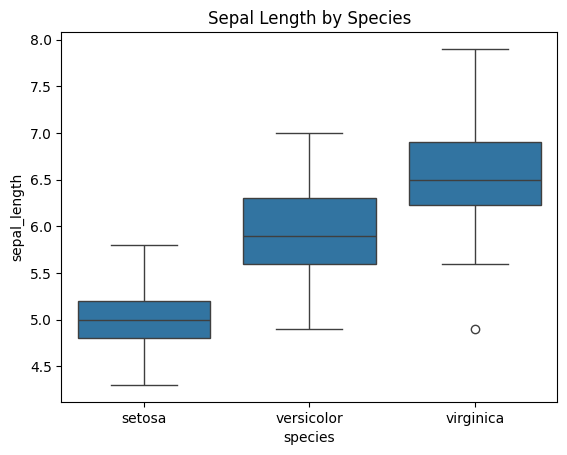

In [10]:
#c)

sns.boxplot(x="species",y="sepal_length",data=df)
plt.title("Sepal Length by Species")
plt.show()

In [27]:
#e)
import statsmodels.formula.api as smf
model=smf.ols('sepal_length~C(species)',data=df)

#f)
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("sepal_length ~ species", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           sepal_length   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     119.3
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.67e-31
Time:                        15:30:29   Log-Likelihood:                -111.73
No. Observations:                 150   AIC:                             229.5
Df Residuals:                     147   BIC:                             238.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.0060      0.073     68.762      0.000       4.862       5.150
species[T.versicolor]     0.9300      0.103      9.033      0.000       0.727       1.133
species[T.virginica]      1.5820      0.103     15.366      0.000       1.379       1.785
==============================================================================
Omnibus:                        1.188   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.552   Jarque-Bera (JB):                0.785
Skew:                           0.119   Prob(JB):                        0.675
Kurtosis:                       3.263   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
p_val=anova_table.iloc[0,3]
alpha=0.05
if p_val > alpha:
    print(f"Pvale:{p_val:.4f}so fail to reject Ho: residuals following normal distribution")
else:
    print(f"Pvale:{p_val:.4f}so Reject Ho: residuals following normal distribution")


Pvale:0.0000so Reject Ho: residuals following normal distribution


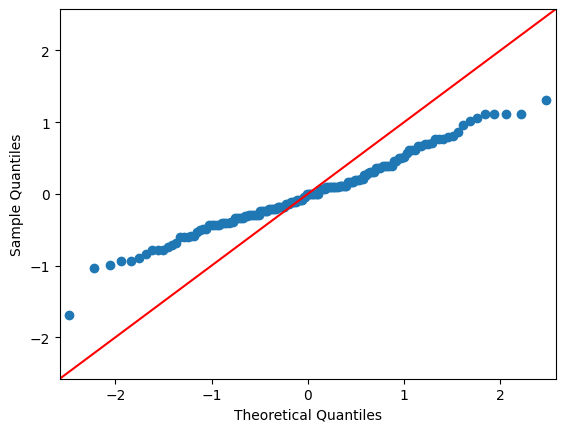

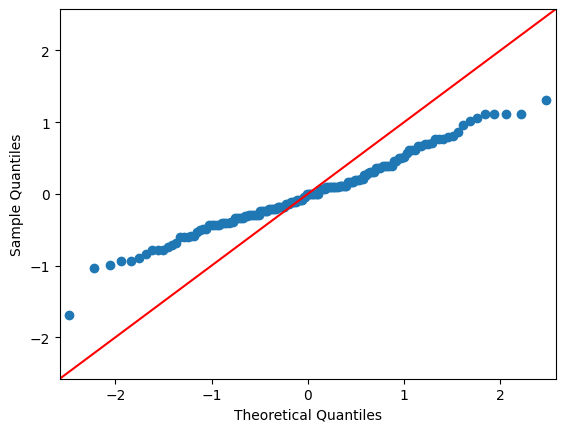

In [13]:
sm.qqplot(model.resid,line='45')

In [40]:
#i)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df.sepal_length, df.species, alpha=0.05)
print(tukey)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------


# Question 2

In [53]:
#a &b 
import numpy as np
n = 20

g1 = np.random.normal(5, 1, n)
g2 = np.random.normal(6, 1, n)
g3 = np.random.normal(7, 1, n)
#print(g1,g2,g3)

In [54]:
from scipy.stats import f_oneway
f_oneway(g1, g2, g3)

F_onewayResult(statistic=np.float64(24.49204904103557), pvalue=np.float64(2.104133053953656e-08))

In [55]:
n = 100
g1 = np.random.normal(5, 1, n)
g2 = np.random.normal(6, 1, n)
g3 = np.random.normal(7, 1, n)

f_oneway(g1, g2, g3)


F_onewayResult(statistic=np.float64(88.4159560095346), pvalue=np.float64(7.48381761156952e-31))

In [59]:
df2=pd.DataFrame({"Y":np.concatenate([g1,g2,g3]),
                  "x":np.repeat(["g1","g2","g3"],n)})
df2.head()

,Y,x
0,6.140656,g1
1,4.211834,g1
2,5.265234,g1
3,4.627728,g1
4,6.174600,g1


In [69]:
model2=smf.ols('Y~C(x)',data=df2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     88.42
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           7.48e-31
Time:                        16:11:45   Log-Likelihood:                -428.57
No. Observations:                 300   AIC:                             863.1
Df Residuals:                     297   BIC:                             874.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0345      0.101     49.612      0.000       4.835       5.234
C(x)[T.g2]     0.8464      0.144      5.898      0.000       0.564       1.129
C(x)[T.g3]     1.9045      0.144     13.271      0.000       1.622       2.187
==============================================================================
Omnibus:                        1.026   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.599   Jarque-Bera (JB):                0.867
Skew:                           0.128   Prob(JB):                        0.648
Kurtosis:                       3.060   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
av_table=sm.stats.anova_lm(model2)
print(av_table)
av_p_val=av_table.iloc[0,3]
alpha=0.05
if av_p_val > alpha:
    print(f"Pvale:{av_p_val:.4f}so fail to reject Ho: All grp have equal mean")
else:
    print(f"Pvale:{av_val:.4f}so Reject Ho: All grp have equal mean")

             df      sum_sq    mean_sq          F        PR(>F)
C(x)        2.0  182.095693  91.047847  88.415956  7.483818e-31
Residual  297.0  305.840842   1.029767        NaN           NaN
Pvale:88.4160so fail to reject Ho: All grp have equal mean


# Question 3

In [78]:
#a)
tips = sns.load_dataset("tips")
print(tips)
tips.info()
tips.describe()


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [79]:
#c)
tips.groupby(["day","sex"])["tip"].describe()


C:\Users\MATH LAB\AppData\Local\Temp\ipykernel_5160\2853311577.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby(["day","sex"])["tip"].describe()


count      mean       std   min     25%    50%     75%    max
day  sex                                                                  
Thur Male     30.0  2.980333  1.353734  1.44  2.0000  2.530  4.0000   6.70
     Female   32.0  2.575625  1.109286  1.25  1.8225  2.005  3.0575   5.17
Fri  Male     10.0  2.693000  1.136428  1.50  1.6650  2.600  3.3750   4.73
     Female    9.0  2.781111  0.938862  1.00  2.5000  3.000  3.2500   4.30
Sat  Male     59.0  3.083898  1.791360  1.00  2.0000  3.000  3.4000  10.00
     Female   28.0  2.801786  1.234480  1.00  2.1500  2.625  3.1025   6.50
Sun  Male     58.0  3.220345  1.271172  1.32  2.0000  3.085  3.9800   6.50
     Female   18.0  3.367222  1.136775  1.01  2.7075  3.500  3.9375   5.20

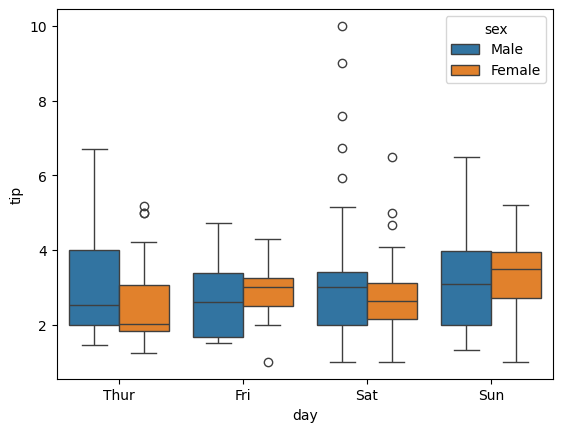

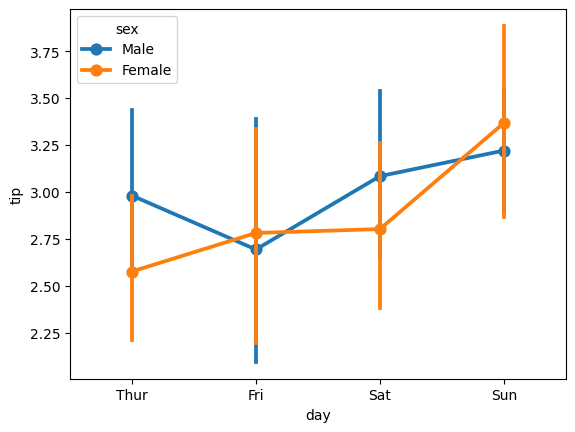

In [80]:
#d)
sns.boxplot(x="day", y="tip", hue="sex", data=tips)
plt.show()

sns.pointplot(x="day", y="tip", hue="sex", data=tips)
plt.show()


In [90]:
#f)
model_int = ols("tip ~ C(day)*C(sex)", data=tips).fit()
anova_int = sm.stats.anova_lm(model_int, typ=2)
anova_int


,sum_sq,df,F,PR(>F)
C(day),7.446900,3.0,1.298061,0.275785
C(sex),1.594561,1.0,0.833839,0.362097
C(day):C(sex),2.785891,3.0,0.485606,0.692600
Residual,451.306151,236.0,NaN,NaN


In [92]:
#i)
model_add = ols("tip ~ C(day) + C(sex)", data=tips).fit()
sm.stats.anova_lm(model_add, typ=2)


,sum_sq,df,F,PR(>F)
C(day),7.446900,3.0,1.306497,0.272937
C(sex),1.594561,1.0,0.839258,0.360533
Residual,454.092042,239.0,NaN,NaN


In [93]:
#j)
model_int.aic, model_add.aic


(np.float64(858.4965658808418), np.float64(853.9981362889007))

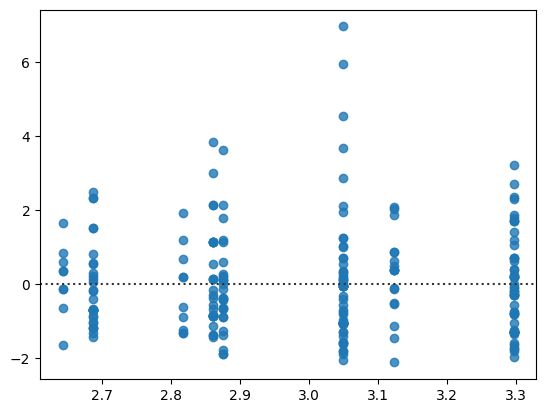

ShapiroResult(statistic=np.float64(0.9039234719865679), pvalue=np.float64(2.1755376400864162e-11))

In [96]:
#K)
sns.residplot(x=model_add.fittedvalues, y=model_add.resid)
plt.show()

ss.shapiro(model_add.resid)


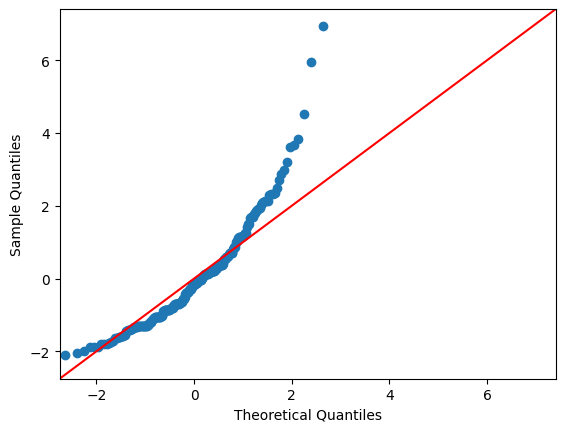

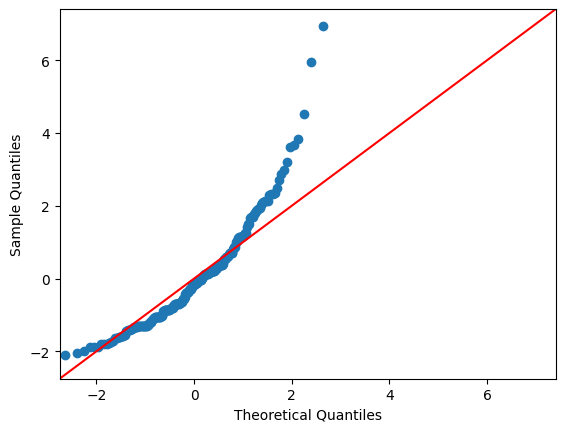

In [97]:
sm.qqplot(model_add.resid,line='45')

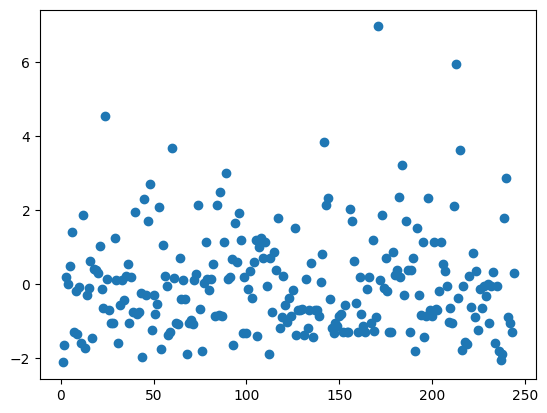

In [100]:
x= range(1 , len(model_add.resid)+1)
plt.scatter(x,model_add.resid)